## Scikit-image
Scikit image it's a huge and very powerful scientific kit for image processing in Python! With this package and little else you can do nearly anything is commonly required in bioimage analysis.

Because this is such a huge package it's worth to spend some time looking at the [documentation website](https://scikit-image.org/).

### Simple color segmentation
We calculate the excess green image from the original RGB image to find the _Arabidopsis_ plant leaves.

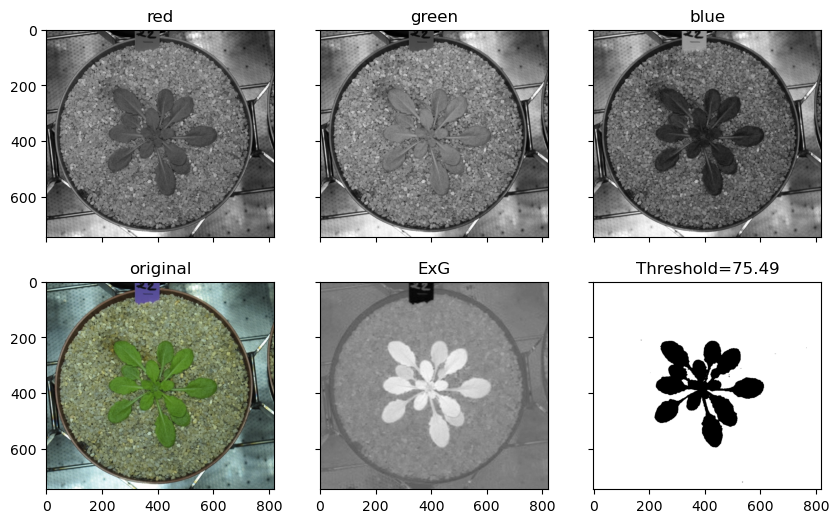

In [1]:
from skimage import io, filters
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# read image
image = io.imread("../data/green_segmentation/arabidopsis.tif")

r = image[:,:,0] 
g = image[:,:,1] 
b = image[:,:,2] 

eg = 2.0*g-1.0*r-1.0*b

t = filters.threshold_otsu(eg)
mask = eg <= t

fig, axes = plt.subplots(2, 3, sharey=True, sharex=True, figsize=(10,6))
ax = axes.ravel()
ax[0].set_title("red")
ax[0].imshow(r,cmap='gray')
ax[1].set_title("green")
ax[1].imshow(g,cmap='gray')
ax[2].set_title("blue")
ax[2].imshow(b,cmap='gray')
ax[3].set_title("original")
ax[3].imshow(image)
ax[4].set_title("ExG")
ax[4].imshow(eg,cmap='gray')
ax[5].set_title("Threshold={:.2f}".format(t))
ax[5].imshow(mask,cmap='gray')


plt.show()

In [2]:
plt.colormaps()

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

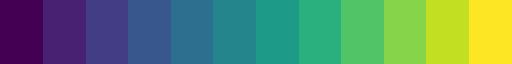

In [3]:
viridis = plt.get_cmap('viridis', 12)
viridis

In [4]:
viridis.colors

array([[0.267004, 0.004874, 0.329415, 1.      ],
       [0.283072, 0.130895, 0.449241, 1.      ],
       [0.262138, 0.242286, 0.520837, 1.      ],
       [0.220057, 0.343307, 0.549413, 1.      ],
       [0.177423, 0.437527, 0.557565, 1.      ],
       [0.143343, 0.522773, 0.556295, 1.      ],
       [0.119512, 0.607464, 0.540218, 1.      ],
       [0.166383, 0.690856, 0.496502, 1.      ],
       [0.319809, 0.770914, 0.411152, 1.      ],
       [0.525776, 0.833491, 0.288127, 1.      ],
       [0.762373, 0.876424, 0.137064, 1.      ],
       [0.993248, 0.906157, 0.143936, 1.      ]])

the returned list is in the form of an RGBA Nx4 array, where N is the length of the colormap.

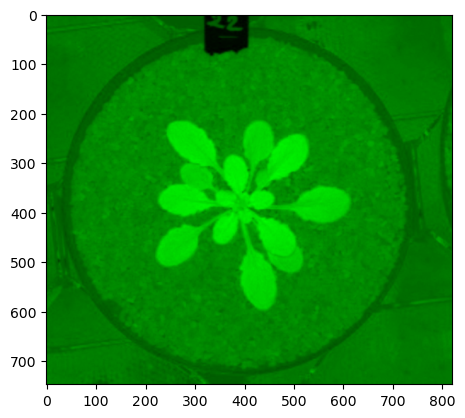

In [5]:
import numpy as np
from matplotlib.colors import ListedColormap
fluogreens = [[0, i/256 , 0, 1] for i in range(256)]
fluogreens
fgreens = ListedColormap(fluogreens)
plt.imshow(eg, cmap=fgreens)

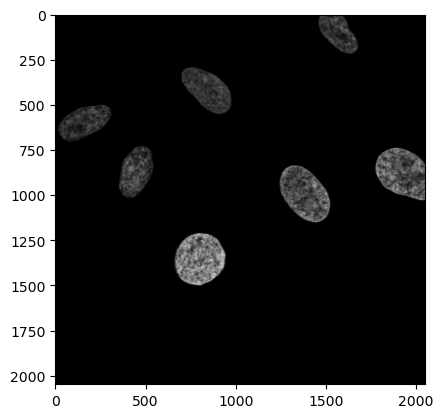

In [6]:
# Because it's a huge package we don't want to import everything
# it's usually better to import only what we need
from skimage import io
img = io.imread('./../data/protein_atlas/1773_H11_1.tif')
img = img[:,:,0]
plt.imshow(img, cmap='gray') # by default matplotlib uses the viridis colormap, here we change it to a grayscale
plt.show()

### Segmentation classical workflow
Let's look at a classical quick workflow to detect and segment particles in an image.

/tmp/ipykernel_9454/3485160776.py:10: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  small_obj_removed = remove_small_objects(filled, min_size=10)


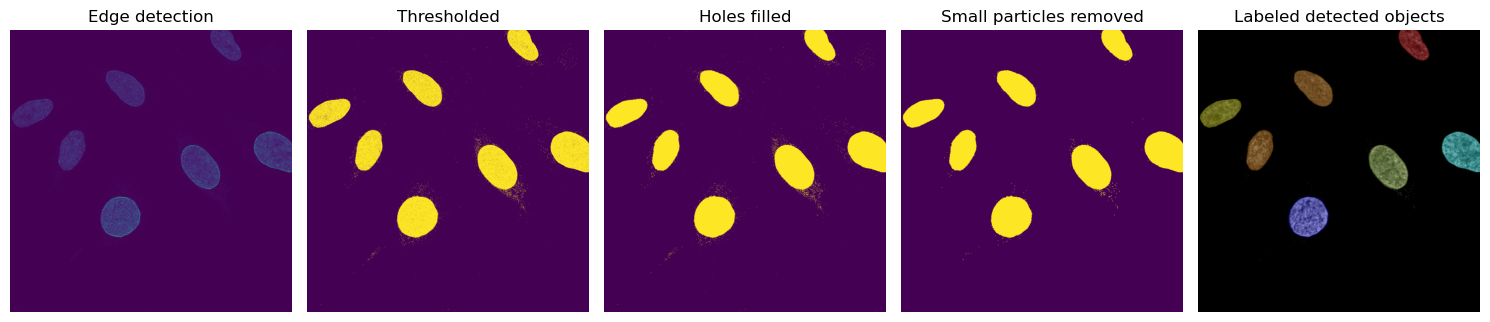

In [7]:
# import only what we need
from skimage.filters import sobel # edge filter
from skimage.morphology import remove_small_holes, remove_small_objects, label # utilities to manipulate segmented images
from skimage.color import label2rgb # create composite image

# Process image from here..
edge_detect = sobel(img)
thresholded = edge_detect > 0.01
filled = remove_small_holes(thresholded, max_size=2000)
small_obj_removed = remove_small_objects(filled, min_size=10)
labeled = label(small_obj_removed)
composite = label2rgb(labeled, img)
# ..to here


# let's use matplotlib subplots to show all the steps!
f, axes = plt.subplots(1,5, figsize=(15, 5))
# axes is now a list of subplots. We can go one-by-one to show a different image
axes[0].imshow(edge_detect)
axes[0].set_title('Edge detection')
axes[1].imshow(thresholded)
axes[1].set_title('Thresholded')
axes[2].imshow(filled)
axes[2].set_title('Holes filled')
axes[3].imshow(small_obj_removed)
axes[3].set_title('Small particles removed')
axes[4].imshow(composite)
axes[4].set_title('Labeled detected objects')

# loop through axes to remove ticks and axis
for ax in axes:
    ax.axis('off')

plt.tight_layout() # this is a wonderful automagic function that optimizes spacings and sizes of all plots to get the best out of image space
plt.show()

In [8]:
# zoom in and inspect Thresholded

### Flat-field correction

We have an uneven background in the image!
We are missing some objects on the lower right.


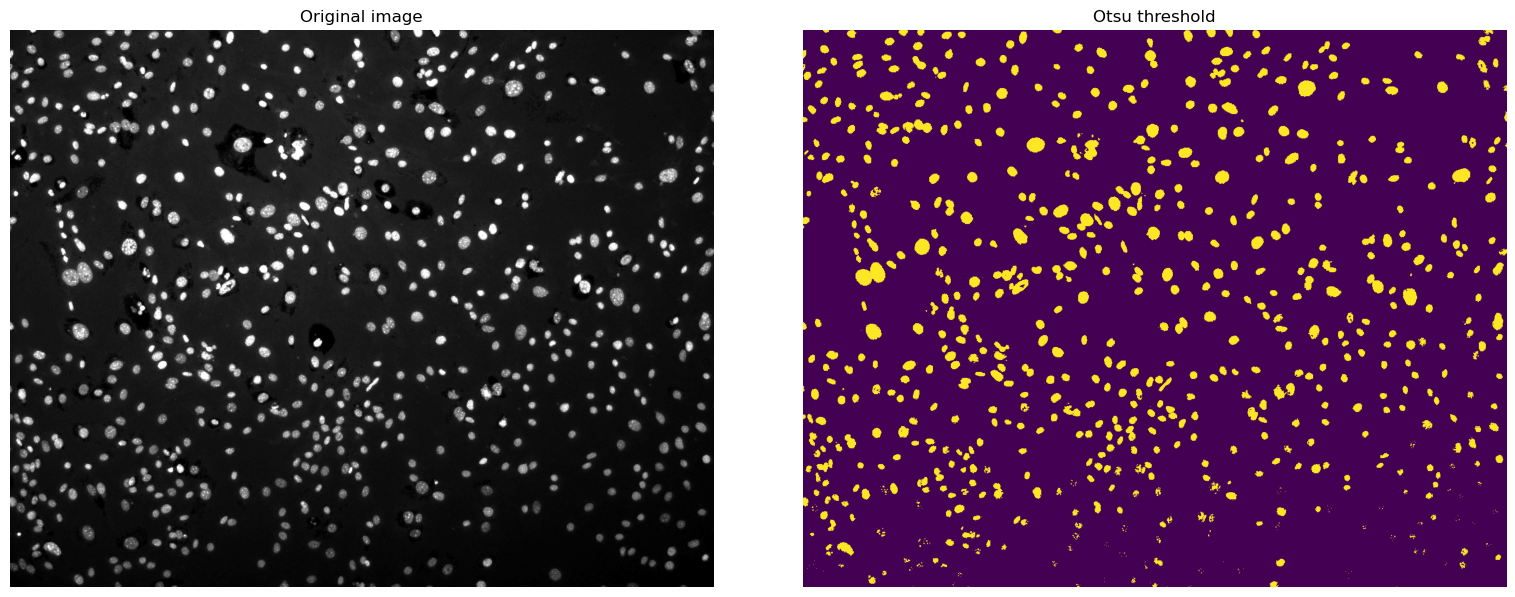

In [9]:
from skimage import io
from skimage.filters import threshold_otsu
from matplotlib import pyplot as plt
import numpy as np

img = io.imread('./../data/flatfield_correction/DAPI.tif')
f, axes = plt.subplots(1,2, figsize=(16, 6))
axes[0].imshow(img, vmin=np.percentile(img, 1), vmax=np.percentile(img, 99), cmap='gray')
axes[0].set_title("Original image")
axes[1].imshow(img > threshold_otsu(img))
axes[1].set_title("Otsu threshold")

print('We have an uneven background in the image!')
print('We are missing some objects on the lower right.')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

We can detect all objects after correction!


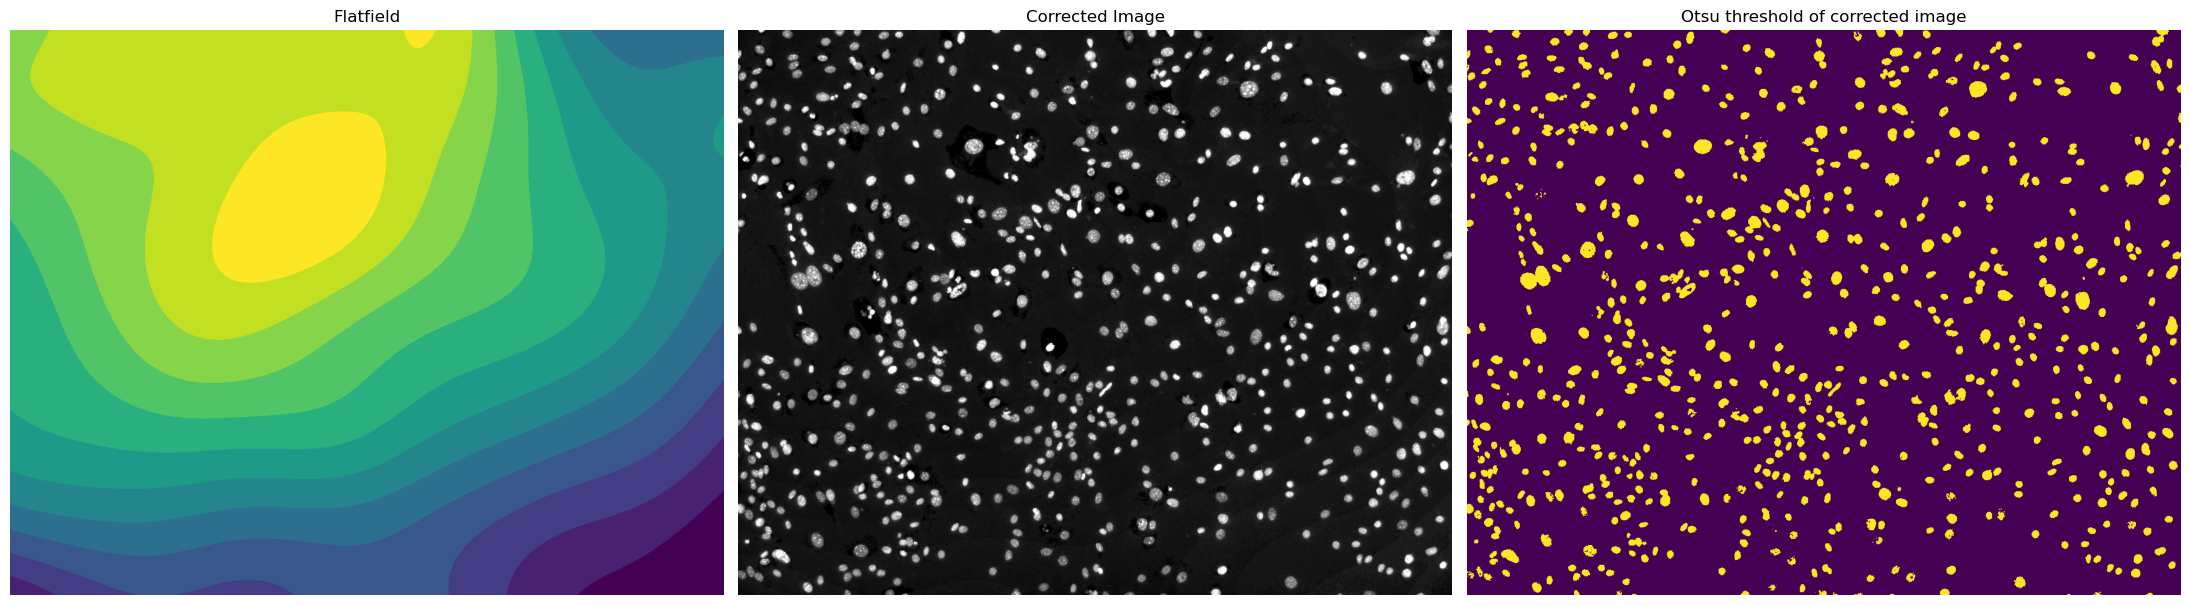

In [10]:
flatfield = io.imread('./../data/flatfield_correction/DAPI_Flatfield.tif')
img_corrected = (img / flatfield) * flatfield.mean()

f, axes = plt.subplots(1,3, figsize=(22, 6))
axes[0].imshow(flatfield, vmin=np.percentile(flatfield, 1), vmax=np.percentile(flatfield, 99))
axes[0].set_title("Flatfield")
axes[1].imshow(img_corrected, vmin=np.percentile(img_corrected, 1), vmax=np.percentile(img_corrected, 99), cmap='gray')
axes[1].set_title("Corrected Image")
axes[2].imshow(img_corrected > threshold_otsu(img_corrected))
axes[2].set_title("Otsu threshold of corrected image")

print('We can detect all objects after correction!')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Watershed segmentation workflow
Let's try to segment a 3D nuclei using a watershed algorithm.

First let's take a look at the data!

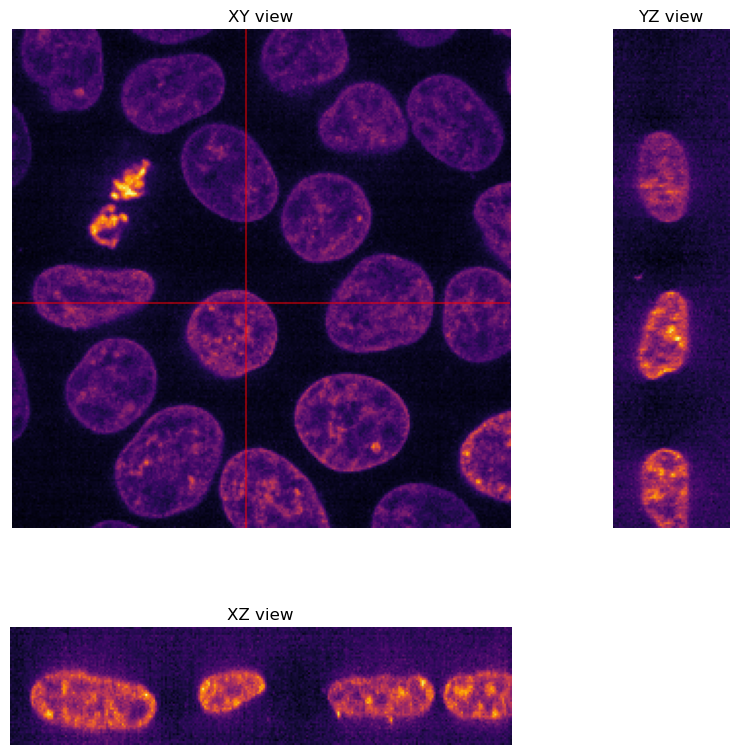

In [11]:
from skimage.data import cells3d # this function has the data
from scipy import ndimage as ndi # note that we are now using another package: scientific python!

stack = cells3d()
nuclei = stack[:, 1, :, :] # extract only the nuclei channel

# create fancy subplot composition to show 3D stack
axd = plt.figure(figsize=(10,10)).subplot_mosaic(
    """
    AAB
    AAB
    CC.
    """
)
# show XY image
axd['A'].imshow(nuclei[30], cmap='inferno')
# Draw line corresponding to X and Y projections
axd['A'].axhline(140, color='red', alpha=0.5)
axd['A'].axvline(120, color='red', alpha=0.5)
# Show YX view
axd['B'].imshow(ndi.rotate(nuclei[:, :, 120], -90), cmap='inferno')
# Show XZ view
axd['C'].imshow(nuclei[:, 140, :], cmap='inferno')
# Set titles
axd['A'].set_title('XY view')
axd['B'].set_title('YZ view')
axd['C'].set_title('XZ view')
# Remove axis for all images
for ax in axd.values():
    ax.axis('off')
plt.show()

Now let's try to do a 3D segmentation using max peak finding and watershed.

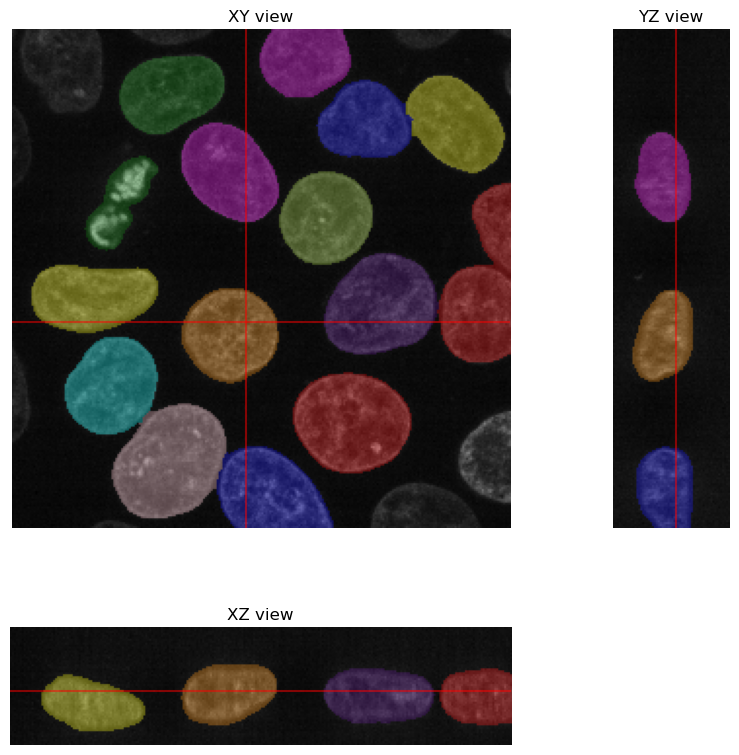

In [12]:
from skimage.filters import threshold_otsu, gaussian
from scipy import ndimage as ndi 
from skimage.feature import peak_local_max
from skimage.segmentation import watershed, clear_border

# Blur original image to smooth noise
nuclei_gauss_low = gaussian(nuclei, sigma=2)
nuclei_gauss_high = gaussian(nuclei, sigma=10)
# Threshold smoothed image with Otsu method
binary = nuclei_gauss_low > threshold_otsu(nuclei_gauss_low)
# Fill holes inside nuclei
binary_cleaned = binary.copy()
for layer_id in range(binary.shape[0]):
    binary_cleaned[layer_id] = ndi.binary_fill_holes(binary[layer_id])
# Calculate the distance transform
dist_transf = ndi.distance_transform_edt(binary_cleaned)
# Find local maxima coordinates from nuclei
coords = peak_local_max(nuclei_gauss_high, 5)
# Transform the max coordinates into an actual image
mask = np.zeros(dist_transf.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)

# Use the distance transform, local max markers and binary mask for watershed
labels = watershed(-dist_transf, markers, mask=binary_cleaned)
# OPTIONAL: remove nuclei touching image borders
# labels_no_borders = clear_border(labels)

# Create composite with original image for visualization
composite = label2rgb(labels, nuclei)

# Create fancy subplot composition to show 3D segmentation
axd = plt.figure(figsize=(10,10)).subplot_mosaic(
    """
    AAB
    AAB
    CC.
    """
)

# Change these variable to see other planes
zslice = 32
yslice = 120
xslice = 150

axd['A'].imshow(composite[zslice])
axd['A'].axhline(xslice, color='red', alpha=0.5)
axd['A'].axvline(yslice, color='red', alpha=0.5)
axd['B'].imshow(ndi.rotate(composite[:, :, yslice], -90))
axd['C'].imshow(composite[:, xslice, :])
axd['B'].axvline(zslice, color='red', alpha=0.5)
axd['C'].axhline(zslice, color='red', alpha=0.5)

axd['A'].set_title('XY view')
axd['B'].set_title('YZ view')
axd['C'].set_title('XZ view')
for ax in axd.values():
    ax.axis('off')

plt.show()

After we have segmented objects usually we want to extract information. This is done all by the `regionprops` function.

Keep in mind that with Python and scikit-image segmented objects should be expresssed as label image: images with unique integer numbers for each pixel belonging to the same object. This is in contrast to ImageJ which uses ROIs.

In [22]:
from skimage.measure import regionprops
props = regionprops(labeled) # regionprops returns a list of measurements for each labeled object in the image

# let's check one object area
print(props[2].area)

# the only way to get all objects properties is the loop through the elements in the list
# let's calculate the mean average of all nuclei areas
mean_area = 0
for obj in props:
    mean_area += obj.area # += is equivalent to mean_area = mean_area + obj.area. This also applied to -=, /=, *=
mean_area /= len(props)
print(mean_area)

12.0
2691.4087591240877


### Colocalization scatterplot
Here we implemented a similar approach as illustrated in [this ImageJ colocalization plugin](https://imagej.net/imaging/colocalization-analysis#colocalization-threshold).

In [23]:
props

[<RegionProperties: label=1, bbox=(0, 1453, 226, 1683)>,
 <RegionProperties: label=2, bbox=(25, 1446, 28, 1450)>,
 <RegionProperties: label=3, bbox=(179, 1699, 183, 1703)>,
 <RegionProperties: label=4, bbox=(213, 1585, 221, 1592)>,
 <RegionProperties: label=5, bbox=(222, 1656, 231, 1662)>,
 <RegionProperties: label=6, bbox=(249, 1628, 252, 1634)>,
 <RegionProperties: label=7, bbox=(291, 694, 557, 985)>,
 <RegionProperties: label=8, bbox=(304, 697, 307, 705)>,
 <RegionProperties: label=9, bbox=(336, 676, 339, 680)>,
 <RegionProperties: label=10, bbox=(419, 979, 424, 984)>,
 <RegionProperties: label=11, bbox=(436, 731, 440, 735)>,
 <RegionProperties: label=12, bbox=(499, 997, 502, 1001)>,
 <RegionProperties: label=13, bbox=(500, 12, 712, 317)>,
 <RegionProperties: label=14, bbox=(645, 1755, 648, 1759)>,
 <RegionProperties: label=15, bbox=(670, 1679, 674, 1683)>,
 <RegionProperties: label=16, bbox=(705, 109, 709, 113)>,
 <RegionProperties: label=17, bbox=(724, 349, 1024, 549)>,
 <RegionPr

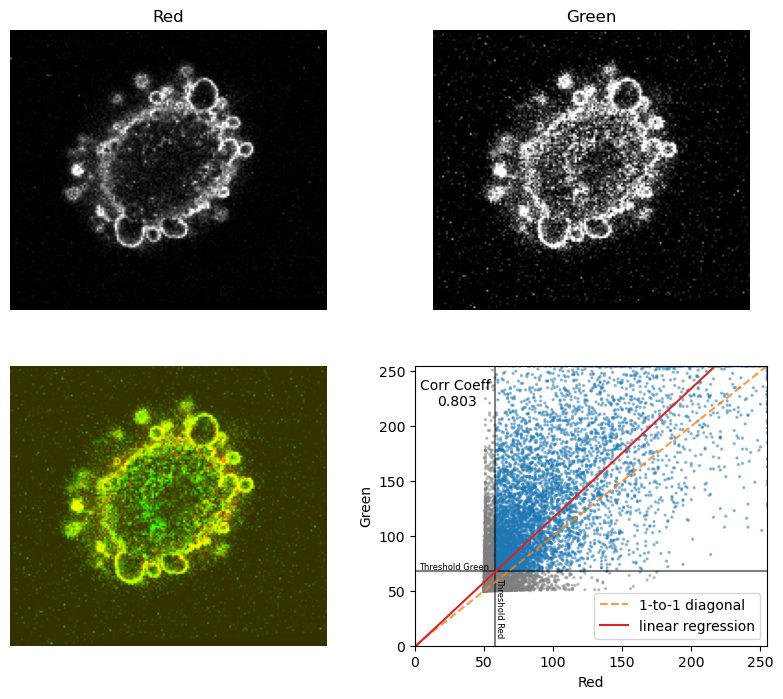

In [24]:
from skimage.io import imread
import numpy as np
from sklearn.linear_model import LinearRegression # package for all things machine learning!
from matplotlib import pyplot as plt

# Open image for colocalization analysis
img = imread('./../data/colocalization/coloc_sample.tif')

# select a single Z slice
zslice = 15
ch1 = img[0, zslice, :, :]
ch2 = img[1, zslice, :, :]


# Use percentile of signal to determine a threshold for each channel
th1 = np.percentile(ch1, 70)
th2 = np.percentile(ch2, 70)

# Perform a linear regression on pixel intensities of ch1 and ch2
x = ch1.ravel().reshape(-1, 1)
Y = ch2.ravel().reshape(-1, 1)
lr = LinearRegression()
lr.fit(x, Y)

# create a new array to use as new x coordinates
new_x = np.linspace(0,255,255)

# Start a new figure to display the colocalization
f, axes = plt.subplots(2,2, figsize=(10,8))
# show red channel
axes[0,0].imshow(ch1, cmap='gray')
axes[0,0].set_title("Red")
# show green channel
axes[0,1].imshow(ch2, cmap='gray')
axes[0,1].set_title("Green")

# create RGB image for showing approximate colocalization
rgb = np.stack([ch1,ch2, np.zeros(ch1.shape, dtype=np.uint8)])
axes[1,0].imshow(np.moveaxis(rgb, 0, -1))

# Make a scatterplot to show colocalization correlation
# Show points colored by the threshold
axes[1,1].scatter(ch1, ch2, s=2, c=np.where(((ch1.ravel()<th1) | (ch2.ravel()<th2)), 'tab:gray', 'tab:blue'), alpha=0.4)
# set limits of axis and add axis labels
axes[1,1].set(xlim=(0,255), ylim=(0,255), xlabel='Red', ylabel='Green')
# add threshold lines
axes[1,1].axvline(th1, color='black', alpha=0.5)
axes[1,1].axhline(th2, color='black', alpha=0.5)
# add threshold annotations
axes[1,1].text(th1, 35, 'Threshold Red', ha='left', va='center', fontsize=6, rotation=-90)
axes[1,1].text(28, th2, 'Threshold Green', ha='center', va='bottom', fontsize=6)
# add diagonal line
axes[1,1].plot(new_x, new_x, color='tab:orange', alpha=0.8, linestyle='--', label='1-to-1 diagonal')
# add linear regression line
axes[1,1].plot(new_x, new_x * lr.coef_[0] + lr.intercept_[0], color='tab:red', label='linear regression') # y = ax + b
# add legend
axes[1,1].legend()
# add correlation coefficient annotation on plot
corr_coeff = np.corrcoef(ch1.ravel(), ch2.ravel())[0,-1]
axes[1,1].text(0.12, 0.9, 'Corr Coeff \n{:.3f}'.format(corr_coeff), transform=axes[1,1].transAxes, ha='center', va='center')

# remove axis for the images
for ax in axes.ravel()[:-1]:
    ax.axis('off')
plt.show()

## Calculate properties for all images
Let's practice what we have learned in DAY 1 and 2 to segment all the images in our data/protein_atlas folder and plot some statistics.

In [27]:
# Let's convert a watershed-based segmentation pipeline into a function
def nuclear_segmentation(img):
    # Blur original image to smooth noise
    nuclei_gauss_low = gaussian(img, sigma=2)
    nuclei_gauss_high = gaussian(img, sigma=20)
    # Threshold smoothed image with Otsu method
    binary = nuclei_gauss_low > threshold_otsu(nuclei_gauss_low)
    # Fill holes inside nuclei and remove small particles
    binary_cleaned = remove_small_objects(ndi.binary_fill_holes(binary), min_size=500)
    # Calculate the distance transform
    dist_transf = ndi.distance_transform_edt(binary_cleaned)
    # Find local maxima coordinates from nuclei
    coords = peak_local_max(nuclei_gauss_high, 5)
    # Transform the max coordinates into an actual image
    mask = np.zeros(dist_transf.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)

    # Use the distance transform, local max markers and binary mask for watershed
    labels = watershed(-dist_transf, markers, mask=binary_cleaned)
    
    return labels

# Glob allows to find all .tif in one go!
from glob import glob
# build a list with all the images
img_list = sorted(glob('./../data/protein_atlas/*.tif'))

# we make a dictionary to store the results in
segmentation_masks = {}
for img_path in img_list:
    img = io.imread(img_path)[:,:,0] # we only keep CH1
    segmentation_masks[img_path] = nuclear_segmentation(img)

/tmp/ipykernel_9454/2683411544.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_cleaned = remove_small_objects(ndi.binary_fill_holes(binary), min_size=500)
/tmp/ipykernel_9454/2683411544.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_cleaned = remove_small_objects(ndi.binary_fill_holes(binar

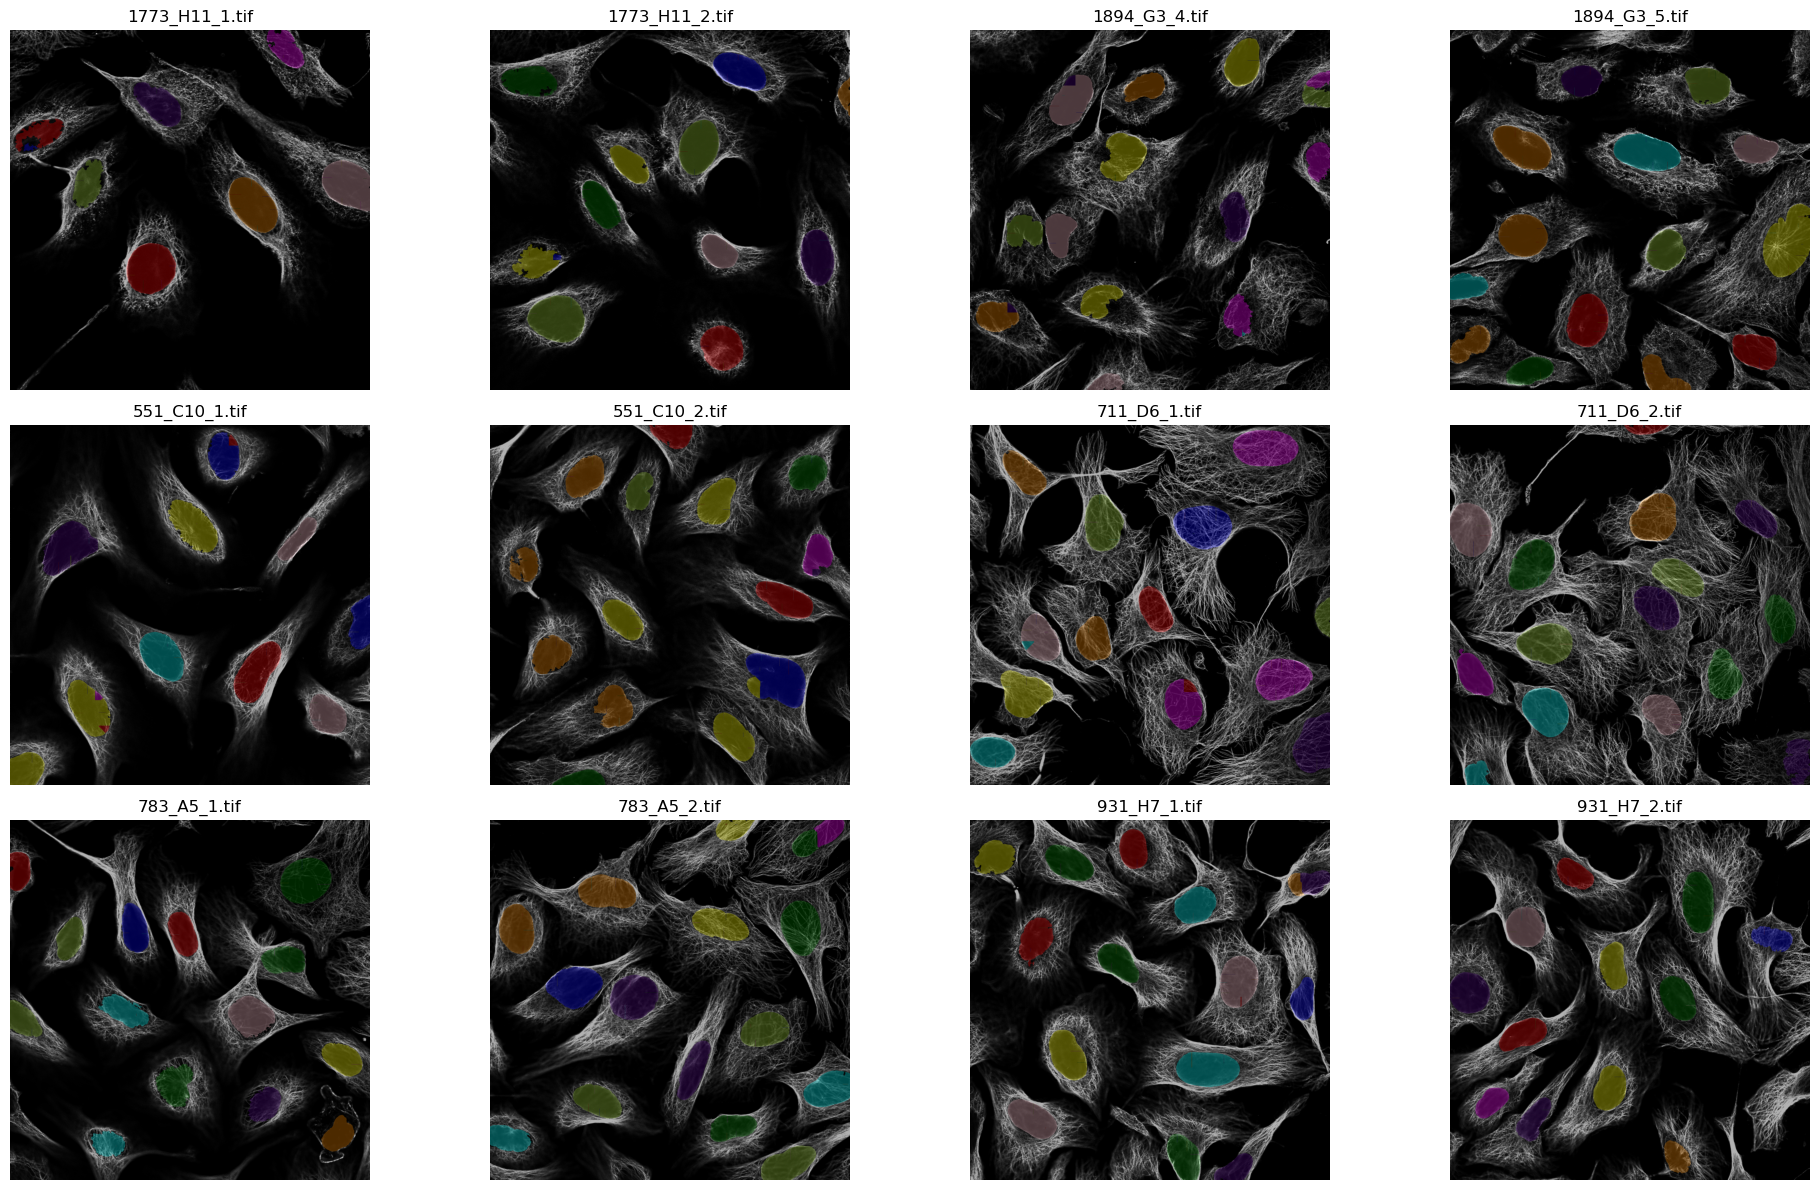

In [28]:
# Let's visualize all the segmentation
# we create a new function to display the overlay
from skimage.exposure import rescale_intensity
import os
def create_overlay(path, labels):
    img = io.imread(path)[:,:,2] # let's create the overlay with CH3
    cells = rescale_intensity(img, in_range=tuple(np.percentile(img, (0.5, 99.5)))) # rescaling the intensity helps with the contrast in the visualization
    # overlay with original image
    overlay = label2rgb(labels, cells)
    return overlay

# We create the panels in the figure
f, axes = plt.subplots(3, int(len(img_list)/3), figsize=(20,12))
# Then we loop through the dictionary we created and create the overlay and display it
for ax_id, (path, labels) in enumerate(segmentation_masks.items()):
    overlay = create_overlay(path, labels)
    ax = axes.ravel()[ax_id]
    ax.imshow(overlay)
    ax.set_title(os.path.basename(path))
    ax.axis('off')

plt.tight_layout()
plt.show()

How does the segmentation look like? What could we improve??

## Measure properties from segmentation labels
If you are interested only in a few properties for the objects in often more useful to use the `regionprops_table` function, which returns a dictionary of arrays (which you should be familiar with by now) with only the properties you want!

In [39]:
# let's create a list to store the measurements
all_props = []

# import the package
from skimage.measure import regionprops_table

# for all label images we calculate the properties
for path, labels in segmentation_masks.items():
    props = regionprops_table(labels, properties=['label','area', 'perimeter', 'eccentricity'])
    props['path'] = path
    all_props.append(props)
    
# we convert all the properties dictionaries into a single Pandas DataFrame
df_all = pd.DataFrame()
for props in all_props:
    props_df = pd.DataFrame(props)
    df_all = pd.concat([props_df, df_all])
    
df_all['filename'] = df_all['path'].str.split('/', expand=True)[4]
df_all['sample'] = df_all['filename'].str.split('_', expand=True)[1]
df_all = df_all.sort_values('sample')
df_all = df_all[df_all["area"]>1000] 

/tmp/ipykernel_9454/1412904575.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=samples, patch_artist=True,


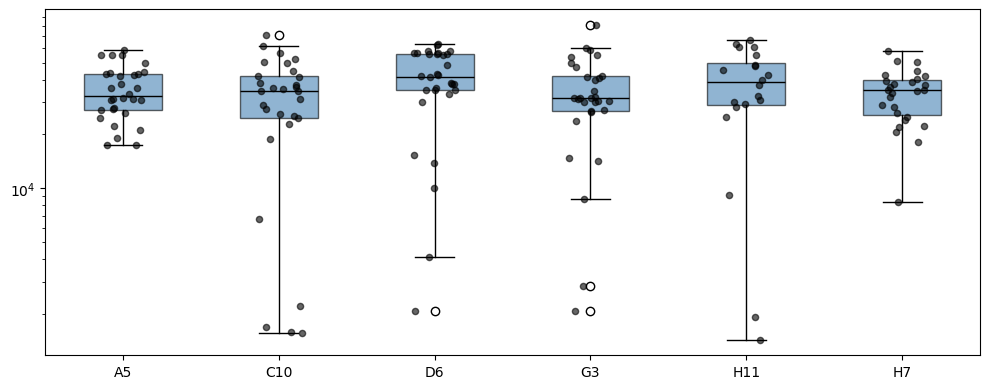

In [40]:
# now we can plot statistics from all images

# create figure
f, ax = plt.subplots(1, figsize=(10, 4))

# get ordered sample names
samples = df_all['sample'].unique()

# gather data groups for boxplot
data_groups = [df_all[df_all['sample'] == s]['area'].values for s in samples]

# boxplot
bp = ax.boxplot(data_groups, labels=samples, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='black'))

# stripplot equivalent: jittered scatter
for i, group in enumerate(data_groups, start=1):
    jitter = np.random.uniform(-0.15, 0.15, size=len(group))
    ax.scatter(np.full(len(group), i) + jitter, group,
               color='black', alpha=0.6, s=20, zorder=3)

# change to log scale
ax.set_yscale('log')
ax.tick_params(direction='out')
plt.tight_layout()
plt.show()